##This project develops a mechanistic bioprocess digital twin for a fed-batch mammalian cell culture process.

## CADET environment setup (Google Colab)
This portfolio version adds **CADET-Core + CADET-Process** for downstream chromatography. CADET-Core is installed from conda-forge; CADET-Process is the recommended Python frontend. In a fresh Colab runtime, run the next setup cell **before other executable cells** because CondaColab restarts the runtime once.

> The upstream mammalian-cell model remains the custom SciPy ODE model. CADET is used where it is strongest: mechanistic downstream separation.


In [13]:
# Run this as the first executable cell in a fresh Google Colab runtime.
!pip install -q condacolab
import condacolab
condacolab.install()  # Colab restarts here once

# AFTER the automatic restart, run the following two commands in a new cell:
# !conda install -y -c conda-forge cadet
# !pip install -q CADET-Process



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


##What we're going to estimate

For the first calibration, estimate these five:

Parameter // 	Meaning

mu_max //	Maximum specific growth rate

K_G //	Glucose half-saturation constant

kd //	Cell death rate

qG //	Glucose consumption rate

qP //	Product formation rate


We'll hold F, G_feed, and the initial conditions fixed, because those are process/input conditions rather than biological parameters we need to infer.

In [14]:
import numpy as np

def bioreactor_model(t, y, params):

    Xv, Xd, G, L, P, V = y

    mu_max = params["mu_max"]
    K_G = params["K_G"]
    kd = params["kd"]
    qG = params["qG"]
    qL = params["qL"]
    qP = params["qP"]
    F = params["F"]
    G_feed = params["G_feed"]

    mu = mu_max * G / (K_G + G)

    dXv_dt = (mu - kd) * Xv
    # Prevent Xv from becoming negative: if Xv is already non-positive and decreasing, set dXv_dt to 0
    if Xv <= 0 and dXv_dt < 0:
        dXv_dt = 0

    dXd_dt = kd * Xv

    glucose_limitation = G / (K_G + G)

    dG_dt = (
    -qG * Xv * glucose_limitation
    + (F / V) * (G_feed - G)
    )
    # Prevent G from becoming negative: if G is already non-positive and decreasing, set dG_dt to 0
    if G <= 0 and dG_dt < 0:
        dG_dt = 0

    dL_dt = qL * Xv - (F / V) * L

    dP_dt = qP * Xv - (F / V) * P

    dV_dt = F

    return [
        dXv_dt,
        dXd_dt,
        dG_dt,
        dL_dt,
        dP_dt,
        dV_dt
    ]

##1 - Synthetic experimental data

In [15]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import os


# ---------------------------------------------------------
# TRUE PROCESS PARAMETERS
# ---------------------------------------------------------
# These are the parameters that represent the hidden
# "real" process that generated our experimental data.
#
# Later, during parameter estimation, the optimizer will
# try to recover these values from noisy observations.
# ---------------------------------------------------------

TRUE_PARAMETERS = {
    "mu_max": 0.03,
    "K_G": 1.0,
    "kd": 0.003,
    "qG": 0.05,
    "qL": 0.02,
    "qP": 0.01,
    "F": 0.01,
    "G_feed": 50.0
}


# ---------------------------------------------------------
# INITIAL CONDITIONS
# ---------------------------------------------------------

INITIAL_CONDITIONS = [
    1.0,   # Xv - viable cells
    0.0,   # Xd - dead cells
    20.0,  # G  - glucose
    0.0,   # L  - lactate
    0.0,   # P  - product
    1.0    # V  - volume
]


# ---------------------------------------------------------
# EXPERIMENTAL SAMPLING TIMES
# ---------------------------------------------------------
#
# Your original model uses 500 time points for smooth
# simulation curves.
#
# Real experiments usually contain far fewer measurements.
# So we simulate continuously but only pretend samples were
# collected every 12 hours.
# ---------------------------------------------------------

measurement_times = np.array([
    0,
    6,
    12,
    18,
    24,
    36,
    48,
    60,
    72,
    84,
    96,
    108,
    120
])

print("Experimental sampling times:")
print(measurement_times)


# ---------------------------------------------------------
# GENERATE THE TRUE PROCESS
# ---------------------------------------------------------

solution = solve_ivp(
    fun=bioreactor_model,
    t_span=(0, 120),
    y0=INITIAL_CONDITIONS,
    args=(TRUE_PARAMETERS,),
    t_eval=measurement_times,
    method="LSODA"
)


if not solution.success:
    raise RuntimeError(
        f"ODE integration failed: {solution.message}"
    )


# ---------------------------------------------------------
# EXTRACT TRUE VALUES
# ---------------------------------------------------------

true_data = pd.DataFrame({

    "time_hr": solution.t,

    "true_viable_cells": solution.y[0],

    "true_dead_cells": solution.y[1],

    "true_glucose": solution.y[2],

    "true_lactate": solution.y[3],

    "true_product": solution.y[4],

    "true_volume": solution.y[5]
})


print("\nTrue simulated process:")
print(true_data.head())


# ---------------------------------------------------------
# ADD EXPERIMENTAL MEASUREMENT NOISE
# ---------------------------------------------------------
#
# Experimental measurements are never perfect.
#
# We'll use percentage-based noise rather than adding the
# same absolute error everywhere.
# ---------------------------------------------------------

rng = np.random.default_rng(seed=42)


experimental_data = pd.DataFrame()

experimental_data["time_hr"] = true_data["time_hr"]


# ---------------------------------------------------------
# VIABLE CELLS
# Approx. 5% measurement noise
# ---------------------------------------------------------

experimental_data["viable_cells"] = (
    true_data["true_viable_cells"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.05,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# DEAD CELLS
# Approx. 8% noise
# ---------------------------------------------------------

experimental_data["dead_cells"] = (
    true_data["true_dead_cells"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.08,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# GLUCOSE
# Approx. 3% measurement noise
# ---------------------------------------------------------

experimental_data["glucose"] = (
    true_data["true_glucose"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.03,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# LACTATE
# Approx. 5% noise
# ---------------------------------------------------------

experimental_data["lactate"] = (
    true_data["true_lactate"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.05,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# PRODUCT
# Approx. 5% noise
# ---------------------------------------------------------

experimental_data["product"] = (
    true_data["true_product"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.05,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# VOLUME
# Assume volume measurement is relatively accurate
# Approx. 1% noise
# ---------------------------------------------------------

experimental_data["volume"] = (
    true_data["true_volume"]
    * (
        1
        + rng.normal(
            loc=0,
            scale=0.01,
            size=len(true_data)
        )
    )
)


# ---------------------------------------------------------
# PREVENT NONPHYSICAL NEGATIVE VALUES
# ---------------------------------------------------------

measured_variables = [
    "viable_cells",
    "dead_cells",
    "glucose",
    "lactate",
    "product",
    "volume"
]

for variable in measured_variables:

    experimental_data[variable] = (
        experimental_data[variable]
        .clip(lower=0)
    )


# ---------------------------------------------------------
# SAVE DATA
# ---------------------------------------------------------

output_path = (
    "data/raw/"
    "synthetic_experimental_data.csv"
)

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

experimental_data.to_csv(
    output_path,
    index=False
)


print("\nSynthetic experimental data:")
print(experimental_data)


print(
    f"\nDataset saved to:\n{output_path}"
)

Experimental sampling times:
[  0   6  12  18  24  36  48  60  72  84  96 108 120]

True simulated process:
   time_hr  true_viable_cells  true_dead_cells  true_glucose  true_lactate  \
0        0           1.000000         0.000000     20.000000      0.000000   
1        6           1.166150         0.019456     21.397106      0.126127   
2       12           1.360554         0.042152     22.576867      0.266725   
3       18           1.587926         0.068637     23.558551      0.425352   
4       24           1.853792         0.099553     24.354938      0.606015   

   true_product  true_volume  
0      0.000000         1.00  
1      0.063063         1.06  
2      0.133363         1.12  
3      0.212676         1.18  
4      0.303008         1.24  

Synthetic experimental data:
    time_hr  viable_cells  dead_cells    glucose    lactate   product  \
0         0      1.015236    0.000000  20.319386   0.000000  0.000000   
1         6      1.105511    0.020184  21.631689   0.130814  

##2 - Parameter estimation

In [16]:
import os
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares




# =========================================================
# 1. Paths
# =========================================================

DATA_PATH = "data/raw/synthetic_experimental_data.csv"
OUTPUT_PATH = "data/processed/fitted_parameters.csv"

os.makedirs("data/processed", exist_ok=True)


# =========================================================
# 2. Load data
# =========================================================

data = pd.read_csv(DATA_PATH)

measurement_times = data["time_hr"].values


# =========================================================
# 3. Initial conditions
# =========================================================

INITIAL_CONDITIONS = [
    1.0,    # Xv
    0.0,    # Xd
    20.0,   # G
    0.0,    # L
    0.0,    # P
    1.0     # V
]


# =========================================================
# 4. Fixed parameters
# =========================================================

FIXED_PARAMETERS = {
    "F": 0.01,
    "G_feed": 50.0,
    "qL": 0.02
}


# =========================================================
# 5. Parameters being estimated
# =========================================================

PARAMETER_NAMES = [
    "mu_max",
    "K_G",
    "kd",
    "qG",
    "qP"
]


# =========================================================
# 6. Initial guesses
# =========================================================

INITIAL_GUESS = np.array([
    0.40,
    2.00,
    0.02,
    0.08,
    0.015
])


# =========================================================
# 7. Parameter bounds
# =========================================================

LOWER_BOUNDS = np.array([
    0.005,
    0.05,
    0.001,
    0.01,
    0.001
])

UPPER_BOUNDS = np.array([
    0.80,
    10.0,
    0.10,
    0.50,
    0.10
])


# =========================================================
# 8. Build parameter dictionary
# =========================================================

def build_parameters(values):

    return {
        "mu_max": values[0],
        "K_G": values[1],
        "kd": values[2],
        "qG": values[3],
        "qP": values[4],
        "qL": FIXED_PARAMETERS["qL"],
        "F": FIXED_PARAMETERS["F"],
        "G_feed": FIXED_PARAMETERS["G_feed"]
    }


# =========================================================
# 9. Simulate model
# =========================================================

def simulate(values):

    parameters = build_parameters(values)

    solution = solve_ivp(
        bioreactor_model,
        (
            measurement_times[0],
            measurement_times[-1]
        ),
        INITIAL_CONDITIONS,
        args=(parameters,),
        t_eval=measurement_times,
        method="LSODA",
        rtol=1e-5,
        atol=1e-7
    )

    if not solution.success:
        return None

    # Check for numerical problems
    if not np.all(np.isfinite(solution.y)):
        return None

    return solution.y


# =========================================================
# 10. Residual function
# =========================================================

evaluation_count = 0


def residuals(values):

    global evaluation_count

    evaluation_count += 1

    # Print progress
    if evaluation_count % 10 == 0:
        print(
            f"Optimization evaluation "
            f"{evaluation_count}"
        )

    simulated = simulate(values)

    # If simulation fails, return a large penalty
    if simulated is None:

        return np.ones(
            len(measurement_times) * 3
        ) * 1e6

    # Model
    Xv_model = simulated[0]
    G_model = simulated[2]
    P_model = simulated[4]

    # Experimental
    Xv_data = data["viable_cells"].values
    G_data = data["glucose"].values
    P_data = data["product"].values

    # Scale each variable
    Xv_scale = np.std(Xv_data)
    G_scale = np.std(G_data)
    P_scale = np.std(P_data)

    # Avoid division by zero
    Xv_scale = max(Xv_scale, 1e-8)
    G_scale = max(G_scale, 1e-8)
    P_scale = max(P_scale, 1e-8)

    residual_Xv = (
        Xv_model - Xv_data
    ) / Xv_scale

    residual_G = (
        G_model - G_data
    ) / G_scale

    residual_P = (
        P_model - P_data
    ) / P_scale

    return np.concatenate([
        residual_Xv,
        residual_G,
        residual_P
    ])


# =========================================================
# 11. Run optimization
# =========================================================

print("\nStarting parameter estimation...")
print("This should normally complete in a reasonable amount")
print("of time with the constrained parameter space.\n")


result = least_squares(
    residuals,
    x0=INITIAL_GUESS,
    bounds=(
        LOWER_BOUNDS,
        UPPER_BOUNDS
    ),
    method="trf",
    max_nfev=100,
    verbose=1
)


# =========================================================
# 12. Results
# =========================================================

fitted_parameters = build_parameters(
    result.x
)


print("\n")
print("=" * 70)
print("PARAMETER ESTIMATION RESULTS")
print("=" * 70)

for i, name in enumerate(PARAMETER_NAMES):

    print(
        f"{name:10s} | "
        f"initial = {INITIAL_GUESS[i]:.6f} | "
        f"fitted = {result.x[i]:.6f}"
    )

print("=" * 70)

print(
    f"\nOptimization success: "
    f"{result.success}"
)

print(
    f"Function evaluations: "
    f"{result.nfev}"
)

print(
    f"Final cost: "
    f"{result.cost:.6f}"
)

print(
    f"Termination message:\n"
    f"{result.message}"
)


# =========================================================
# 13. Save results
# =========================================================

results_table = pd.DataFrame({
    "parameter": PARAMETER_NAMES,
    "initial_guess": INITIAL_GUESS,
    "fitted_value": result.x
})


results_table.to_csv(
    OUTPUT_PATH,
    index=False
)


print(
    f"\nResults saved to:\n"
    f"{OUTPUT_PATH}"
)


Starting parameter estimation...
This should normally complete in a reasonable amount
of time with the constrained parameter space.

Optimization evaluation 10
Optimization evaluation 20
Optimization evaluation 30
Optimization evaluation 40
Optimization evaluation 50
Optimization evaluation 60
Optimization evaluation 70
Optimization evaluation 80
Optimization evaluation 90
Optimization evaluation 100
Optimization evaluation 110
Optimization evaluation 120
Optimization evaluation 130
Optimization evaluation 140
Optimization evaluation 150
Optimization evaluation 160
Optimization evaluation 170
Optimization evaluation 180
Optimization evaluation 190
Optimization evaluation 200
Optimization evaluation 210
Optimization evaluation 220
Optimization evaluation 230
Optimization evaluation 240
Optimization evaluation 250
Optimization evaluation 260
Optimization evaluation 270
`ftol` termination condition is satisfied.
Function evaluations 52, initial cost 7.0860e+03, final cost 6.9299e-02, fir

##3 - Model validation


Fitted parameters:
mu_max     = 0.071706
K_G        = 0.699806
kd         = 0.043577
qG         = 0.048136
qP         = 0.010017
F          = 0.010000
G_feed     = 50.000000
qL         = 0.050000


MODEL VALIDATION RESULTS
    variable     RMSE      MAE       R2
viable_cells 0.212726 0.155320 0.998871
     glucose 0.563065 0.431774 0.991362
     product 0.066164 0.044415 0.999051

Validation metrics saved to:
data/processed/validation_metrics.csv
Model predictions saved to:
data/processed/model_predictions.csv


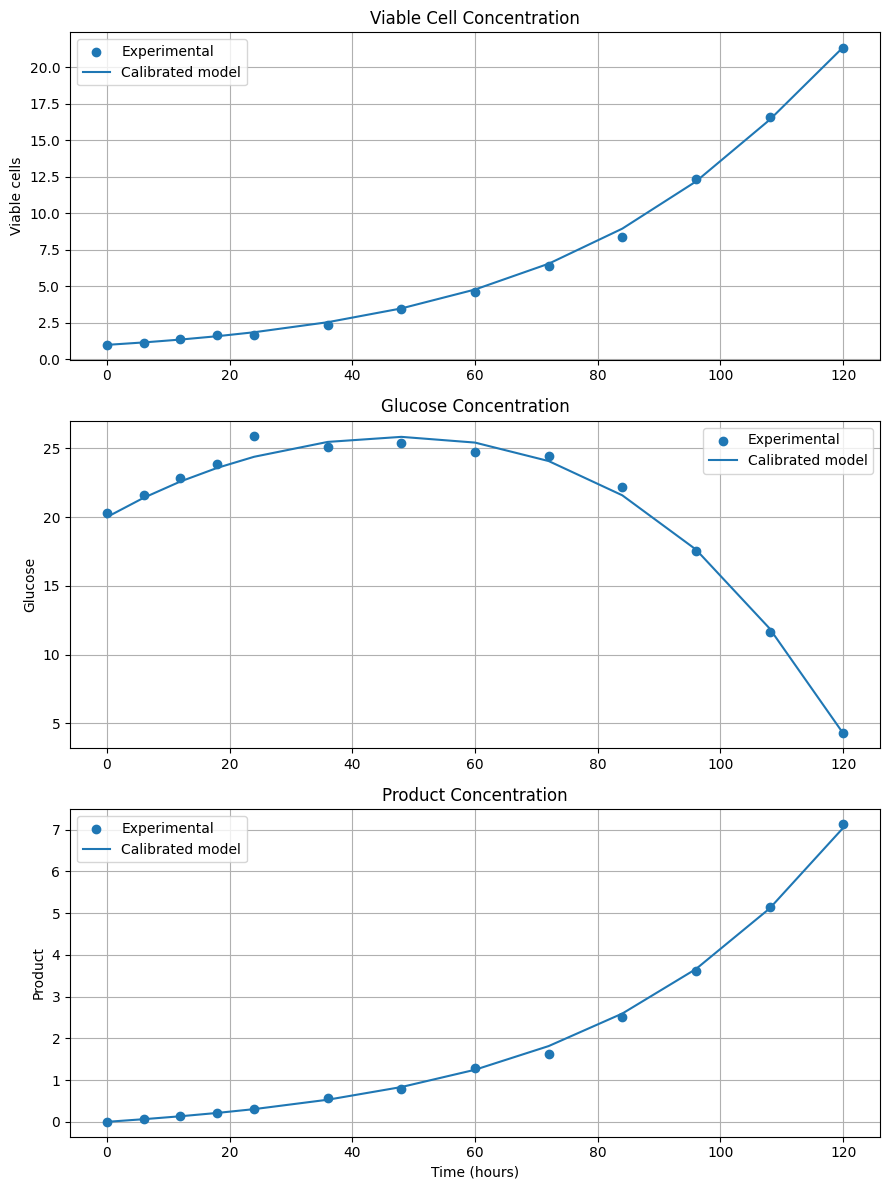


Validation plot saved to:
figures/model_validation.png


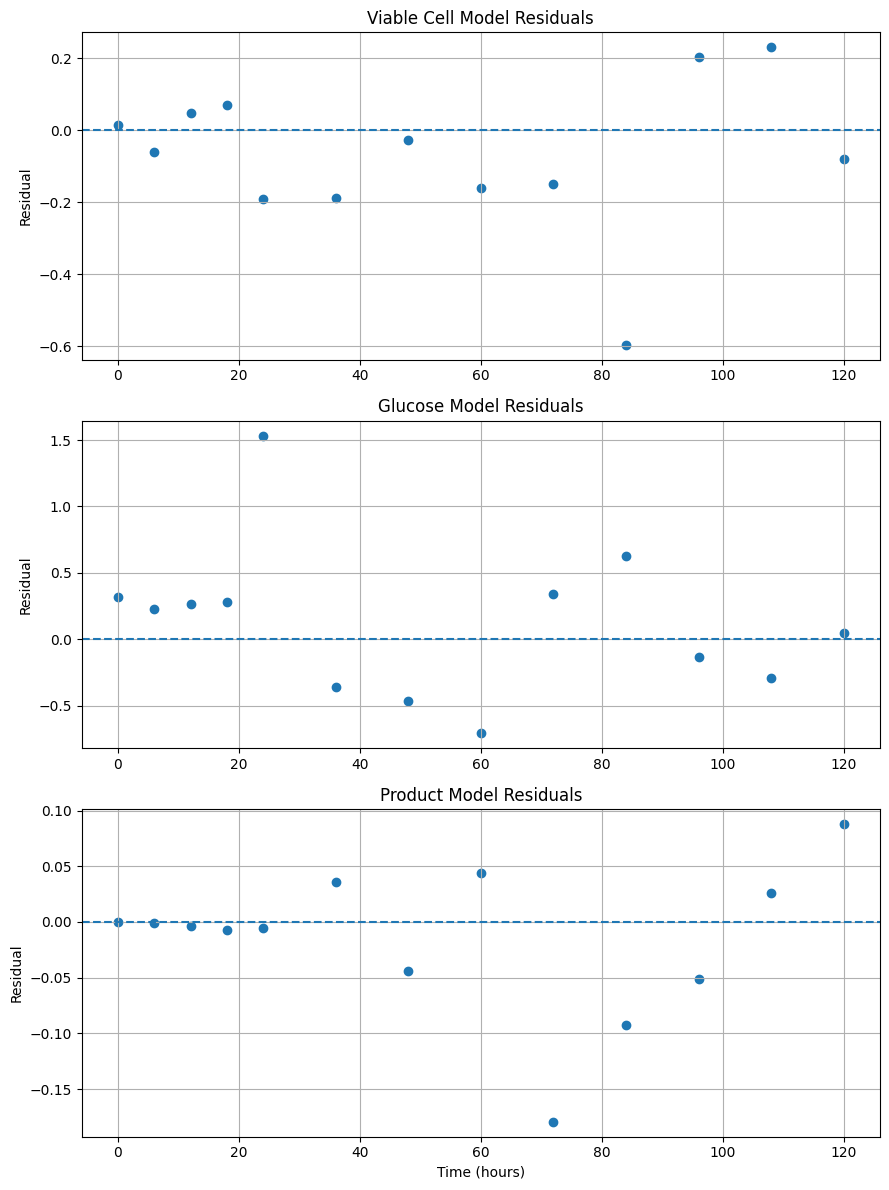

Residual plot saved to:
figures/model_residuals.png

Phase 3 validation complete.


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error, r2_score



# =========================================================
# 1. Paths
# =========================================================

DATA_PATH = "data/raw/synthetic_experimental_data.csv"
PARAMETER_PATH = "data/processed/fitted_parameters.csv"

FIGURE_DIR = "figures"
RESULTS_DIR = "data/processed"

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


# =========================================================
# 2. Load experimental data
# =========================================================

data = pd.read_csv(DATA_PATH)

time = data["time_hr"].values


# =========================================================
# 3. Load fitted parameters
# =========================================================

parameter_table = pd.read_csv(PARAMETER_PATH)

fitted_parameters = dict(
    zip(
        parameter_table["parameter"],
        parameter_table["fitted_value"]
    )
)


# Add fixed parameters from the process
fitted_parameters["F"] = 0.01
fitted_parameters["G_feed"] = 50.0

# qL was not estimated in Phase 9
fitted_parameters["qL"] = 0.05


print("\nFitted parameters:")
for name, value in fitted_parameters.items():
    print(f"{name:10s} = {value:.6f}")


# =========================================================
# 4. Initial conditions
# =========================================================

INITIAL_CONDITIONS = [
    1.0,   # Xv
    0.0,   # Xd
    20.0,  # G
    0.0,   # L
    0.0,   # P
    1.0    # V
]


# =========================================================
# 5. Simulate calibrated model
# =========================================================

solution = solve_ivp(
    fun=bioreactor_model,
    t_span=(time[0], time[-1]),
    y0=INITIAL_CONDITIONS,
    args=(fitted_parameters,),
    t_eval=time,
    method="LSODA"
)


if not solution.success:
    raise RuntimeError(
        f"ODE integration failed: {solution.message}"
    )


# Extract model predictions

predicted = pd.DataFrame({
    "time_hr": solution.t,
    "viable_cells_pred": solution.y[0],
    "dead_cells_pred": solution.y[1],
    "glucose_pred": solution.y[2],
    "lactate_pred": solution.y[3],
    "product_pred": solution.y[4],
    "volume_pred": solution.y[5]
})


# =========================================================
# 6. Define variables to validate
# =========================================================

validation_variables = {
    "viable_cells": "viable_cells_pred",
    "glucose": "glucose_pred",
    "product": "product_pred"
}


# =========================================================
# 7. Calculate performance metrics
# =========================================================

metrics = []


for experimental_name, prediction_name in validation_variables.items():

    observed = data[experimental_name].values
    predicted_values = predicted[prediction_name].values

    rmse = np.sqrt(
        mean_squared_error(
            observed,
            predicted_values
        )
    )

    r2 = r2_score(
        observed,
        predicted_values
    )

    mae = np.mean(
        np.abs(
            observed - predicted_values
        )
    )

    metrics.append({
        "variable": experimental_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


metrics_df = pd.DataFrame(metrics)


# =========================================================
# 8. Print validation metrics
# =========================================================

print("\n")
print("=" * 70)
print("MODEL VALIDATION RESULTS")
print("=" * 70)

print(
    metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)


# =========================================================
# 9. Save metrics
# =========================================================

metrics_path = (
    f"{RESULTS_DIR}/validation_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(
    f"\nValidation metrics saved to:\n"
    f"{metrics_path}"
)


# =========================================================
# 10. Create prediction dataset
# =========================================================

comparison = data.copy()

comparison["viable_cells_pred"] = (
    predicted["viable_cells_pred"]
)

comparison["dead_cells_pred"] = (
    predicted["dead_cells_pred"]
)

comparison["glucose_pred"] = (
    predicted["glucose_pred"]
)

comparison["lactate_pred"] = (
    predicted["lactate_pred"]
)

comparison["product_pred"] = (
    predicted["product_pred"]
)

comparison["volume_pred"] = (
    predicted["volume_pred"]
)


comparison_path = (
    f"{RESULTS_DIR}/model_predictions.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print(
    f"Model predictions saved to:\n"
    f"{comparison_path}"
)


# =========================================================
# 11. Plot model vs experimental data
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 12)
)


# ---------------------------------------------------------
# Viable cells
# ---------------------------------------------------------

axes[0].scatter(
    data["time_hr"],
    data["viable_cells"],
    label="Experimental",
    zorder=3
)

axes[0].plot(
    predicted["time_hr"],
    predicted["viable_cells_pred"],
    label="Calibrated model"
)

axes[0].set_ylabel("Viable cells")
axes[0].set_title("Viable Cell Concentration")
axes[0].legend()
axes[0].grid(True)


# ---------------------------------------------------------
# Glucose
# ---------------------------------------------------------

axes[1].scatter(
    data["time_hr"],
    data["glucose"],
    label="Experimental",
    zorder=3
)

axes[1].plot(
    predicted["time_hr"],
    predicted["glucose_pred"],
    label="Calibrated model"
)

axes[1].set_ylabel("Glucose")
axes[1].set_title("Glucose Concentration")
axes[1].legend()
axes[1].grid(True)


# ---------------------------------------------------------
# Product
# ---------------------------------------------------------

axes[2].scatter(
    data["time_hr"],
    data["product"],
    label="Experimental",
    zorder=3
)

axes[2].plot(
    predicted["time_hr"],
    predicted["product_pred"],
    label="Calibrated model"
)

axes[2].set_xlabel("Time (hours)")
axes[2].set_ylabel("Product")
axes[2].set_title("Product Concentration")
axes[2].legend()
axes[2].grid(True)


plt.tight_layout()


validation_plot_path = (
    f"{FIGURE_DIR}/model_validation.png"
)

plt.savefig(
    validation_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nValidation plot saved to:\n"
    f"{validation_plot_path}"
)


# =========================================================
# 12. Residual analysis
# =========================================================

residuals = pd.DataFrame({
    "time_hr": time,

    "viable_cells_residual":
        data["viable_cells"].values
        - predicted["viable_cells_pred"].values,

    "glucose_residual":
        data["glucose"].values
        - predicted["glucose_pred"].values,

    "product_residual":
        data["product"].values
        - predicted["product_pred"].values
})


residuals_path = (
    f"{RESULTS_DIR}/model_residuals.csv"
)

residuals.to_csv(
    residuals_path,
    index=False
)


# =========================================================
# 13. Residual plots
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 12)
)


axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].scatter(
    time,
    residuals["viable_cells_residual"]
)

axes[0].set_ylabel("Residual")
axes[0].set_title(
    "Viable Cell Model Residuals"
)

axes[0].grid(True)


axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].scatter(
    time,
    residuals["glucose_residual"]
)

axes[1].set_ylabel("Residual")
axes[1].set_title(
    "Glucose Model Residuals"
)

axes[1].grid(True)


axes[2].axhline(
    0,
    linestyle="--"
)

axes[2].scatter(
    time,
    residuals["product_residual"]
)

axes[2].set_xlabel("Time (hours)")
axes[2].set_ylabel("Residual")
axes[2].set_title(
    "Product Model Residuals"
)

axes[2].grid(True)


plt.tight_layout()


residual_plot_path = (
    f"{FIGURE_DIR}/model_residuals.png"
)

plt.savefig(
    residual_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"Residual plot saved to:\n"
    f"{residual_plot_path}"
)

print("\nPhase 3 validation complete.")

##3.2 - Validation


Fitted parameter set
mu_max      : 0.071706
K_G         : 0.699806
kd          : 0.043577
qG          : 0.048136
qP          : 0.010017
F           : 0.010000
G_feed      : 50.000000
qL          : 0.020000


MODEL VALIDATION METRICS
    variable    RMSE     MAE      R2
viable_cells 0.21144 0.15545 0.99889
     glucose 0.56231 0.43245 0.99139
     product 0.06552 0.04387 0.99907


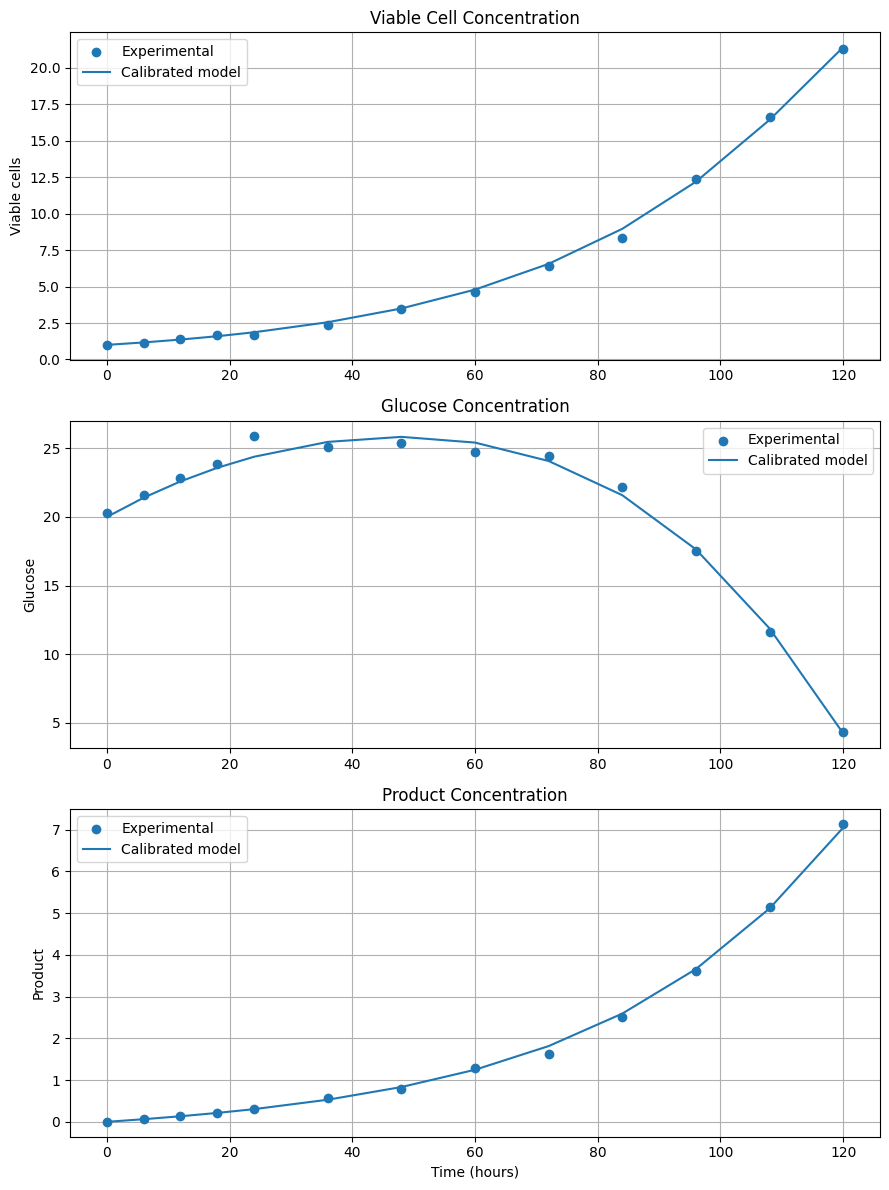

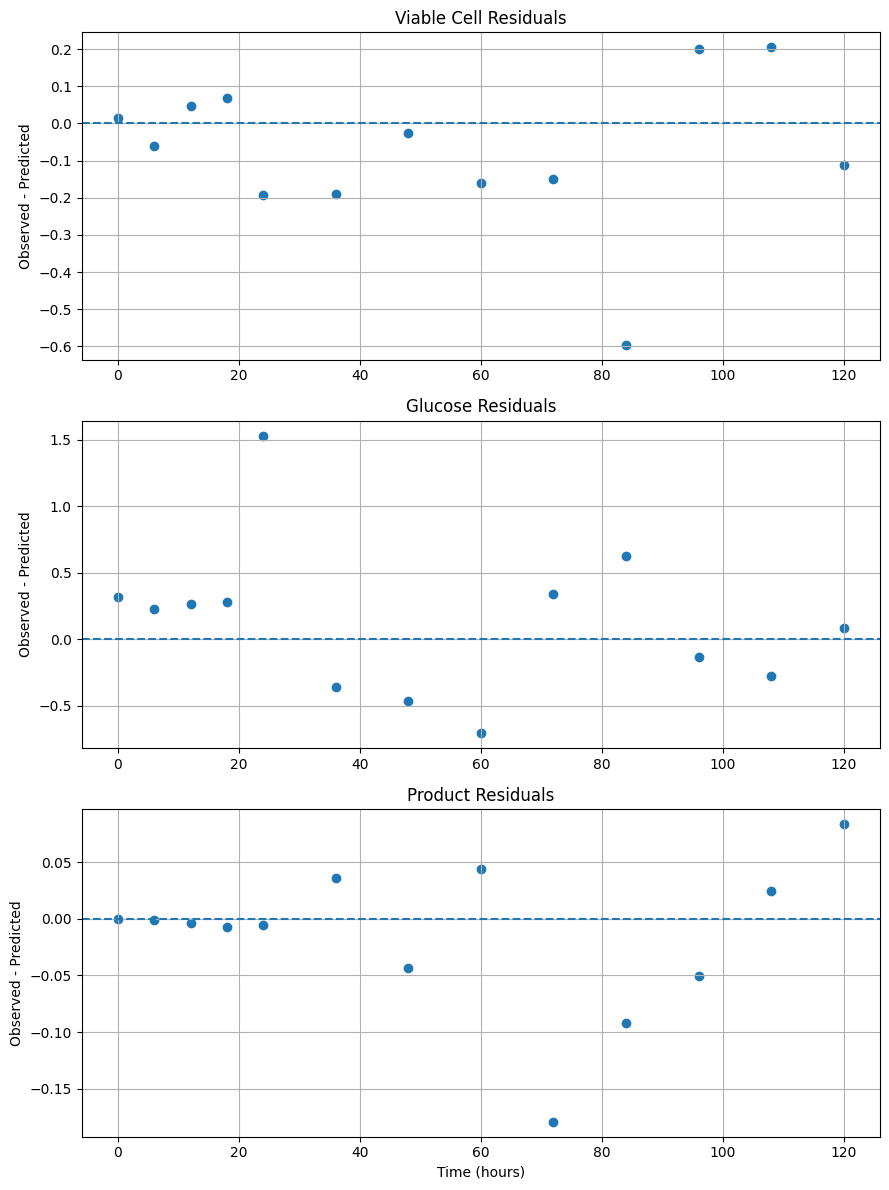

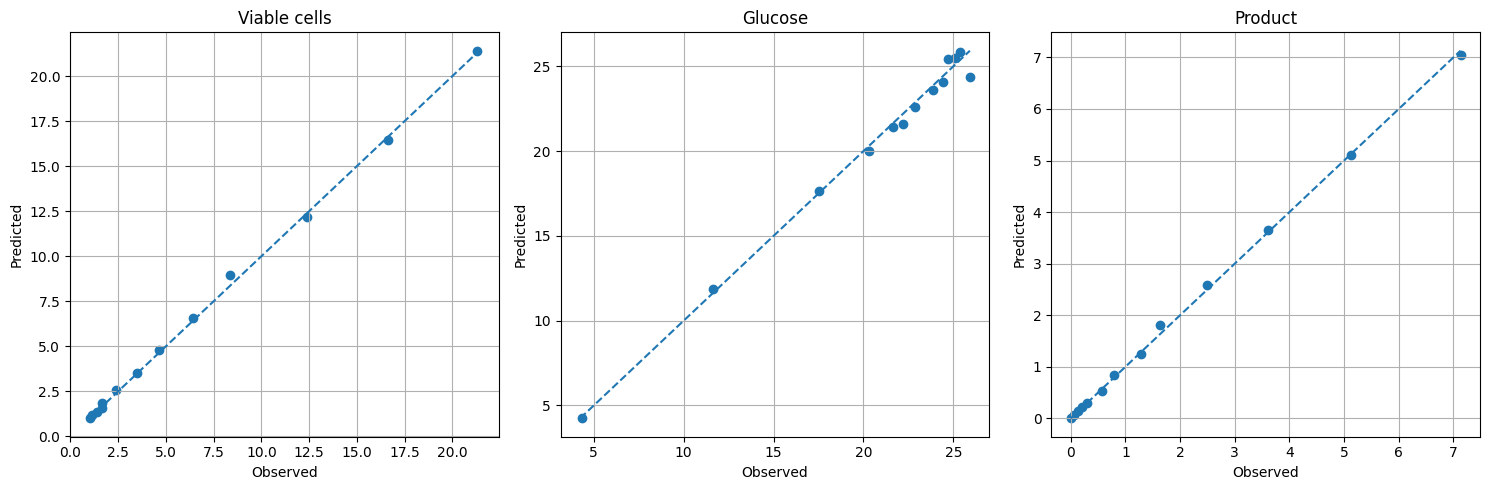


Validation complete.

Metrics saved to:
data/processed/validation_metrics.csv

Predictions saved to:
data/processed/model_predictions.csv

Residuals saved to:
data/processed/model_residuals.csv

Validation figure saved to:
figures/model_validation.png

Residual figure saved to:
figures/model_residuals.png

Observed-vs-predicted figure saved to:
figures/observed_vs_predicted.png


In [18]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# =========================================================
# 1. File paths
# =========================================================

DATA_PATH = "data/raw/synthetic_experimental_data.csv"
PARAMETER_PATH = "data/processed/fitted_parameters.csv"

RESULTS_DIR = "data/processed"
FIGURE_DIR = "figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# =========================================================
# 2. Load experimental data
# =========================================================

data = pd.read_csv(DATA_PATH)

time = data["time_hr"].to_numpy()


# =========================================================
# 3. Load fitted parameters from Phase 9
# =========================================================

parameter_table = pd.read_csv(PARAMETER_PATH)

fitted_parameters = dict(
    zip(
        parameter_table["parameter"],
        parameter_table["fitted_value"]
    )
)


# =========================================================
# 4. Add parameters that were fixed during calibration
# =========================================================

fitted_parameters["F"] = 0.01
fitted_parameters["G_feed"] = 50.0

# If qL was held fixed in Phase 9:
fitted_parameters["qL"] = 0.02


print("\nFitted parameter set")
print("=" * 50)

for name, value in fitted_parameters.items():
    print(f"{name:12s}: {value:.6f}")

print("=" * 50)


# =========================================================
# 5. Initial conditions
# =========================================================

INITIAL_CONDITIONS = [
    1.0,    # viable cells
    0.0,    # dead cells
    20.0,   # glucose
    0.0,    # lactate
    0.0,    # product
    1.0     # volume
]


# =========================================================
# 6. Simulate calibrated mechanistic model
# =========================================================

solution = solve_ivp(
    fun=bioreactor_model,
    t_span=(time[0], time[-1]),
    y0=INITIAL_CONDITIONS,
    args=(fitted_parameters,),
    t_eval=time,
    method="LSODA",
    rtol=1e-6,
    atol=1e-8
)


if not solution.success:
    raise RuntimeError(
        f"ODE integration failed: {solution.message}"
    )


if not np.all(np.isfinite(solution.y)):
    raise RuntimeError(
        "Validation simulation produced non-finite values."
    )


# =========================================================
# 7. Put predictions into dataframe
# =========================================================

predictions = pd.DataFrame({
    "time_hr": solution.t,

    "viable_cells_pred":
        solution.y[0],

    "dead_cells_pred":
        solution.y[1],

    "glucose_pred":
        solution.y[2],

    "lactate_pred":
        solution.y[3],

    "product_pred":
        solution.y[4],

    "volume_pred":
        solution.y[5]
})


# =========================================================
# 8. Variables included in validation
# =========================================================

VARIABLES = {
    "viable_cells": "viable_cells_pred",
    "glucose": "glucose_pred",
    "product": "product_pred"
}


# =========================================================
# 9. Calculate model performance metrics
# =========================================================

metric_results = []


for observed_name, predicted_name in VARIABLES.items():

    observed = data[observed_name].to_numpy()

    predicted = predictions[
        predicted_name
    ].to_numpy()


    rmse = np.sqrt(
        mean_squared_error(
            observed,
            predicted
        )
    )


    mae = mean_absolute_error(
        observed,
        predicted
    )


    r2 = r2_score(
        observed,
        predicted
    )


    metric_results.append({
        "variable": observed_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


metrics_df = pd.DataFrame(
    metric_results
)


# =========================================================
# 10. Display metrics
# =========================================================

print("\n")
print("=" * 70)
print("MODEL VALIDATION METRICS")
print("=" * 70)

print(
    metrics_df.to_string(
        index=False,
        float_format=lambda value:
            f"{value:.5f}"
    )
)

print("=" * 70)


# =========================================================
# 11. Save validation metrics
# =========================================================

metrics_path = os.path.join(
    RESULTS_DIR,
    "validation_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)


# =========================================================
# 12. Create combined observed/predicted dataset
# =========================================================

comparison = data.copy()


for column in predictions.columns:

    if column != "time_hr":
        comparison[column] = predictions[column]


comparison_path = os.path.join(
    RESULTS_DIR,
    "model_predictions.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)


# =========================================================
# 13. Calculate residuals
#
# residual = observed - predicted
# =========================================================

residuals = pd.DataFrame({
    "time_hr": time
})


for observed_name, predicted_name in VARIABLES.items():

    residuals[
        f"{observed_name}_residual"
    ] = (

        data[
            observed_name
        ].to_numpy()

        -

        predictions[
            predicted_name
        ].to_numpy()
    )


residual_path = os.path.join(
    RESULTS_DIR,
    "model_residuals.csv"
)

residuals.to_csv(
    residual_path,
    index=False
)


# =========================================================
# 14. Plot: observed vs calibrated model
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 12)
)


# ---------------------------------------------------------
# Viable cells
# ---------------------------------------------------------

axes[0].scatter(
    data["time_hr"],
    data["viable_cells"],
    label="Experimental",
    zorder=3
)

axes[0].plot(
    predictions["time_hr"],
    predictions["viable_cells_pred"],
    label="Calibrated model"
)

axes[0].set_title(
    "Viable Cell Concentration"
)

axes[0].set_ylabel(
    "Viable cells"
)

axes[0].legend()
axes[0].grid(True)


# ---------------------------------------------------------
# Glucose
# ---------------------------------------------------------

axes[1].scatter(
    data["time_hr"],
    data["glucose"],
    label="Experimental",
    zorder=3
)

axes[1].plot(
    predictions["time_hr"],
    predictions["glucose_pred"],
    label="Calibrated model"
)

axes[1].set_title(
    "Glucose Concentration"
)

axes[1].set_ylabel(
    "Glucose"
)

axes[1].legend()
axes[1].grid(True)


# ---------------------------------------------------------
# Product
# ---------------------------------------------------------

axes[2].scatter(
    data["time_hr"],
    data["product"],
    label="Experimental",
    zorder=3
)

axes[2].plot(
    predictions["time_hr"],
    predictions["product_pred"],
    label="Calibrated model"
)

axes[2].set_title(
    "Product Concentration"
)

axes[2].set_xlabel(
    "Time (hours)"
)

axes[2].set_ylabel(
    "Product"
)

axes[2].legend()
axes[2].grid(True)


plt.tight_layout()


validation_figure_path = os.path.join(
    FIGURE_DIR,
    "model_validation.png"
)

plt.savefig(
    validation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 15. Residual plots
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 12)
)


residual_columns = [
    "viable_cells_residual",
    "glucose_residual",
    "product_residual"
]

titles = [
    "Viable Cell Residuals",
    "Glucose Residuals",
    "Product Residuals"
]


for ax, column, title in zip(
    axes,
    residual_columns,
    titles
):

    ax.axhline(
        y=0,
        linestyle="--"
    )

    ax.scatter(
        residuals["time_hr"],
        residuals[column]
    )

    ax.set_title(title)

    ax.set_ylabel(
        "Observed - Predicted"
    )

    ax.grid(True)


axes[-1].set_xlabel(
    "Time (hours)"
)


plt.tight_layout()


residual_figure_path = os.path.join(
    FIGURE_DIR,
    "model_residuals.png"
)

plt.savefig(
    residual_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 16. Observed vs predicted scatter plots
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


plot_variables = [
    (
        "viable_cells",
        "viable_cells_pred",
        "Viable cells"
    ),

    (
        "glucose",
        "glucose_pred",
        "Glucose"
    ),

    (
        "product",
        "product_pred",
        "Product"
    )
]


for ax, observed_name, predicted_name, title in [

    (
        axes[0],
        "viable_cells",
        "viable_cells_pred",
        "Viable cells"
    ),

    (
        axes[1],
        "glucose",
        "glucose_pred",
        "Glucose"
    ),

    (
        axes[2],
        "product",
        "product_pred",
        "Product"
    )
]:

    observed = data[
        observed_name
    ].to_numpy()

    predicted = predictions[
        predicted_name
    ].to_numpy()


    ax.scatter(
        observed,
        predicted
    )


    minimum = min(
        observed.min(),
        predicted.min()
    )

    maximum = max(
        observed.max(),
        predicted.max()
    )


    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )


    ax.set_xlabel(
        "Observed"
    )

    ax.set_ylabel(
        "Predicted"
    )

    ax.set_title(title)

    ax.grid(True)


plt.tight_layout()


observed_predicted_path = os.path.join(
    FIGURE_DIR,
    "observed_vs_predicted.png"
)

plt.savefig(
    observed_predicted_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 17. Finish
# =========================================================

print("\nValidation complete.")

print(
    f"\nMetrics saved to:\n"
    f"{metrics_path}"
)

print(
    f"\nPredictions saved to:\n"
    f"{comparison_path}"
)

print(
    f"\nResiduals saved to:\n"
    f"{residual_path}"
)

print(
    f"\nValidation figure saved to:\n"
    f"{validation_figure_path}"
)

print(
    f"\nResidual figure saved to:\n"
    f"{residual_figure_path}"
)

print(
    f"\nObserved-vs-predicted figure saved to:\n"
    f"{observed_predicted_path}"
)

##4 - Sensitivity


Calibrated parameters
mu_max      : 0.071706
K_G         : 0.699806
kd          : 0.043577
qG          : 0.048136
qP          : 0.010017
F           : 0.010000
G_feed      : 50.000000
qL          : 0.020000

Baseline process outputs
max_viable_cells    : 21.414458
final_product       : 7.046518
final_glucose       : 4.242266
IVCD                : 828.401379

Sensitivity results saved to:
data/processed/sensitivity_results.csv

Parameter sensitivity ranking
parameter  mean_sensitivity
   mu_max          7.271218
       kd          5.547064
       qG          1.561497
      K_G          0.527993
       qP          0.250000


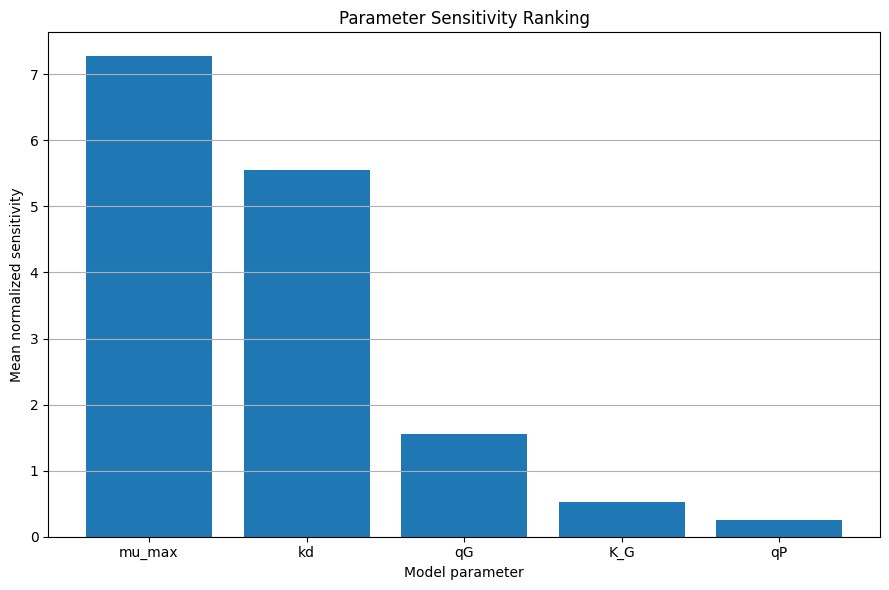

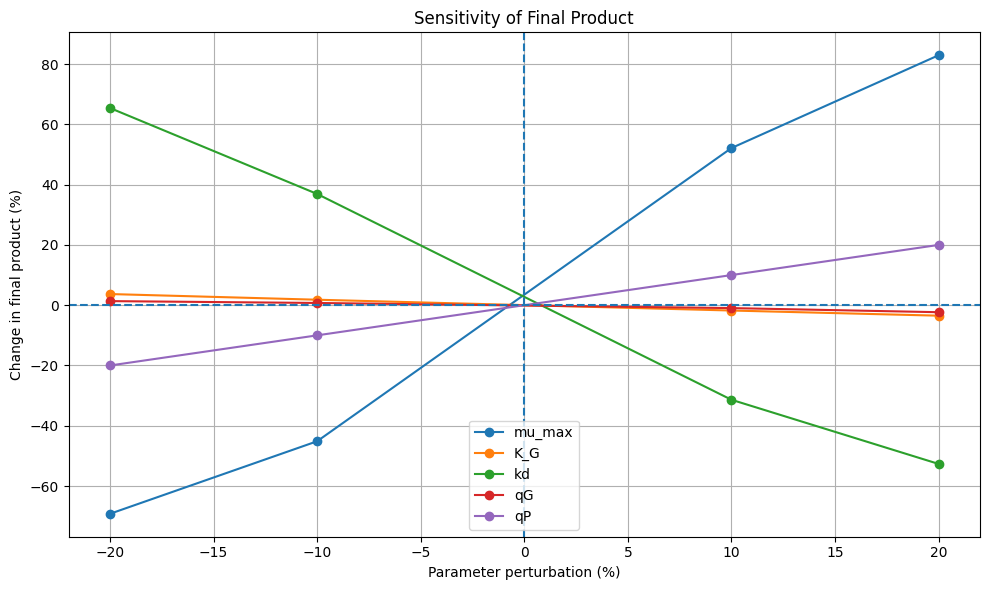


Phase 4 sensitivity analysis complete.


In [19]:
import os

import numpy as np
import pandas as pd

from scipy.integrate import solve_ivp
from scipy.integrate import trapezoid

# =========================================================
# 1. Paths
# =========================================================

PARAMETER_PATH = (
    "data/processed/fitted_parameters.csv"
)

RESULTS_DIR = "data/processed"
FIGURE_DIR = "figures"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)


# =========================================================
# 2. Load calibrated parameters
# =========================================================

parameter_table = pd.read_csv(
    PARAMETER_PATH
)

calibrated_parameters = dict(
    zip(
        parameter_table["parameter"],
        parameter_table["fitted_value"]
    )
)


# Fixed parameters
calibrated_parameters["F"] = 0.01
calibrated_parameters["G_feed"] = 50.0
calibrated_parameters["qL"] = 0.02


print("\nCalibrated parameters")
print("=" * 50)

for name, value in calibrated_parameters.items():

    print(
        f"{name:12s}: {value:.6f}"
    )

print("=" * 50)


# =========================================================
# 3. Initial conditions
# =========================================================

INITIAL_CONDITIONS = [
    1.0,    # Xv
    0.0,    # Xd
    20.0,   # G
    0.0,    # L
    0.0,    # P
    1.0     # V
]


# =========================================================
# 4. Simulation time
# =========================================================

time = np.linspace(
    0,
    120,
    500
)


# =========================================================
# 5. Simulation function
# =========================================================

def simulate(parameters):

    solution = solve_ivp(
        bioreactor_model,

        (
            time[0],
            time[-1]
        ),

        INITIAL_CONDITIONS,

        args=(parameters,),

        t_eval=time,

        method="LSODA",

        rtol=1e-6,

        atol=1e-8
    )


    if not solution.success:

        raise RuntimeError(
            solution.message
        )


    if not np.all(
        np.isfinite(solution.y)
    ):

        raise RuntimeError(
            "Simulation produced "
            "non-finite values."
        )


    return solution


# =========================================================
# 6. Calculate process outputs
# =========================================================

def calculate_outputs(solution):

    Xv = solution.y[0]

    P = solution.y[4]

    G = solution.y[2]


    max_viable_cells = np.max(Xv)

    final_product = P[-1]

    final_glucose = G[-1]


    # Integral of viable cell concentration
    IVCD = trapezoid(
        Xv,
        solution.t
    )


    return {
        "max_viable_cells":
            max_viable_cells,

        "final_product":
            final_product,

        "final_glucose":
            final_glucose,

        "IVCD":
            IVCD
    }


# =========================================================
# 7. Baseline simulation
# =========================================================

baseline_solution = simulate(
    calibrated_parameters
)

baseline_outputs = calculate_outputs(
    baseline_solution
)


print("\nBaseline process outputs")
print("=" * 50)

for name, value in baseline_outputs.items():

    print(
        f"{name:20s}: "
        f"{value:.6f}"
    )

print("=" * 50)


# =========================================================
# 8. Parameters to analyze
# =========================================================

parameters_to_analyze = [
    "mu_max",
    "K_G",
    "kd",
    "qG",
    "qP"
]


# =========================================================
# 9. Perturbation levels
# =========================================================

perturbations = [
    -0.20,
    -0.10,
     0.10,
     0.20
]


# =========================================================
# 10. Run one-at-a-time sensitivity analysis
# =========================================================

results = []


for parameter_name in parameters_to_analyze:

    baseline_value = (
        calibrated_parameters[
            parameter_name
        ]
    )


    for perturbation in perturbations:

        modified_parameters = (
            calibrated_parameters.copy()
        )


        modified_parameters[
            parameter_name
        ] = (

            baseline_value
            * (1 + perturbation)
        )


        solution = simulate(
            modified_parameters
        )


        outputs = calculate_outputs(
            solution
        )


        row = {
            "parameter":
                parameter_name,

            "perturbation":
                perturbation,

            "parameter_value":
                modified_parameters[
                    parameter_name
                ]
        }


        # Add output values
        for output_name, output_value in outputs.items():

            row[
                output_name
            ] = output_value


        # Calculate percent change
        for output_name in baseline_outputs:

            baseline_output = (
                baseline_outputs[
                    output_name
                ]
            )

            current_output = (
                outputs[
                    output_name
                ]
            )


            if abs(baseline_output) > 1e-12:

                percent_change = (

                    (
                        current_output
                        - baseline_output
                    )

                    /

                    baseline_output

                ) * 100

            else:

                percent_change = np.nan


            row[
                f"{output_name}_percent_change"
            ] = percent_change


        results.append(row)


# =========================================================
# 11. Save sensitivity results
# =========================================================

sensitivity_df = pd.DataFrame(
    results
)


output_path = os.path.join(
    RESULTS_DIR,
    "sensitivity_results.csv"
)


sensitivity_df.to_csv(
    output_path,
    index=False
)


print(
    f"\nSensitivity results saved to:"
    f"\n{output_path}"
)


# =========================================================
# 12. Calculate normalized local sensitivity
#
# S = (% change output) /
#     (% change parameter)
# =========================================================

elasticity_results = []


for parameter_name in parameters_to_analyze:

    parameter_rows = (
        sensitivity_df[
            sensitivity_df[
                "parameter"
            ] == parameter_name
        ]
    )


    for output_name in baseline_outputs:

        percent_column = (
            f"{output_name}_percent_change"
        )


        # Use mean absolute response
        mean_response = np.mean(
            np.abs(
                parameter_rows[
                    percent_column
                ]
            )
        )


        # Perturbations are 10% and 20%
        # in magnitude.
        mean_parameter_change = 15.0


        elasticity = (
            mean_response
            / mean_parameter_change
        )


        elasticity_results.append({

            "parameter":
                parameter_name,

            "output":
                output_name,

            "normalized_sensitivity":
                elasticity
        })


elasticity_df = pd.DataFrame(
    elasticity_results
)


elasticity_path = os.path.join(
    RESULTS_DIR,
    "normalized_sensitivity.csv"
)


elasticity_df.to_csv(
    elasticity_path,
    index=False
)


# =========================================================
# 13. Rank parameter importance
# =========================================================

ranking = (

    elasticity_df

    .groupby("parameter")

    ["normalized_sensitivity"]

    .mean()

    .sort_values(
        ascending=False
    )

)


ranking_df = (
    ranking
    .reset_index()
)


ranking_df.rename(
    columns={
        "normalized_sensitivity":
            "mean_sensitivity"
    },
    inplace=True
)


ranking_path = os.path.join(
    RESULTS_DIR,
    "parameter_sensitivity_ranking.csv"
)


ranking_df.to_csv(
    ranking_path,
    index=False
)


print("\nParameter sensitivity ranking")
print("=" * 50)

print(
    ranking_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)

print("=" * 50)


# =========================================================
# 14. Plot parameter ranking
# =========================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    ranking_df["parameter"],
    ranking_df["mean_sensitivity"]
)


plt.xlabel(
    "Model parameter"
)

plt.ylabel(
    "Mean normalized sensitivity"
)

plt.title(
    "Parameter Sensitivity Ranking"
)

plt.grid(
    axis="y"
)


plt.tight_layout()


ranking_figure = os.path.join(
    FIGURE_DIR,
    "parameter_sensitivity_ranking.png"
)


plt.savefig(
    ranking_figure,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =========================================================
# 15. Product sensitivity plot
# =========================================================

product_data = sensitivity_df[
    [
        "parameter",
        "perturbation",
        "final_product_percent_change"
    ]
]


plt.figure(
    figsize=(10, 6)
)


for parameter_name in parameters_to_analyze:

    subset = product_data[
        product_data[
            "parameter"
        ] == parameter_name
    ]


    x = (
        subset["perturbation"]
        * 100
    )

    y = subset[
        "final_product_percent_change"
    ]


    plt.plot(
        x,
        y,
        marker="o",
        label=parameter_name
    )


plt.axhline(
    0,
    linestyle="--"
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Parameter perturbation (%)"
)

plt.ylabel(
    "Change in final product (%)"
)

plt.title(
    "Sensitivity of Final Product"
)

plt.legend()

plt.grid(True)


plt.tight_layout()


product_figure = os.path.join(
    FIGURE_DIR,
    "product_sensitivity.png"
)


plt.savefig(
    product_figure,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\nPhase 4 sensitivity analysis complete."
)

##5 - Process optimization


Baseline process
----------------------------
max_viable_cells: 21.4145
final_viable_cells: 21.4145
final_dead_cells: 36.0992
final_glucose: 4.2423
final_lactate: 14.0694
final_product: 7.0465
final_volume: 2.2000
IVCD: 828.4014


Process optimization
Optimal feed rate: 0.00700
Optimal final product: 7.0854
Product improvement: 0.55%
Final viable cells: 20.0452
Final lactate: 14.1472
Final glucose: 1.9824
Final volume: 1.8400


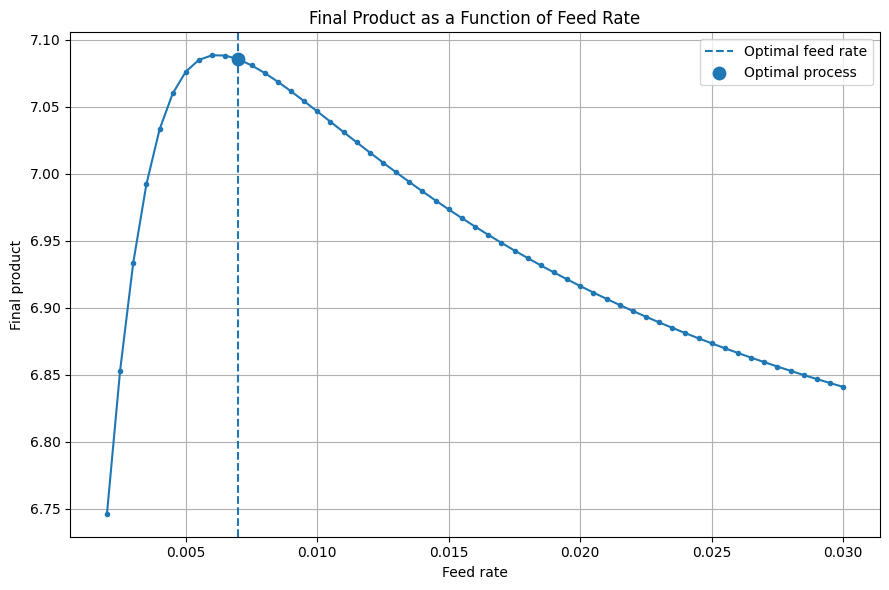

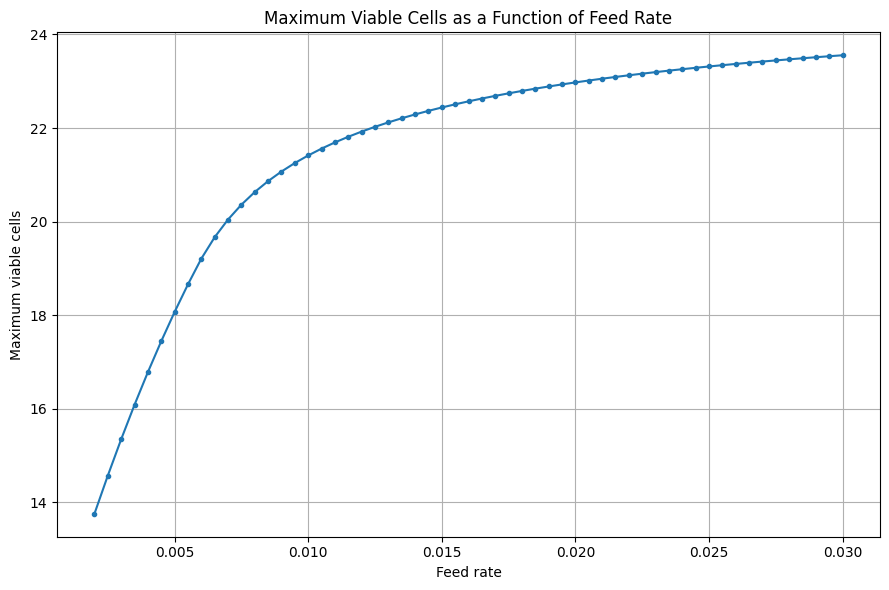

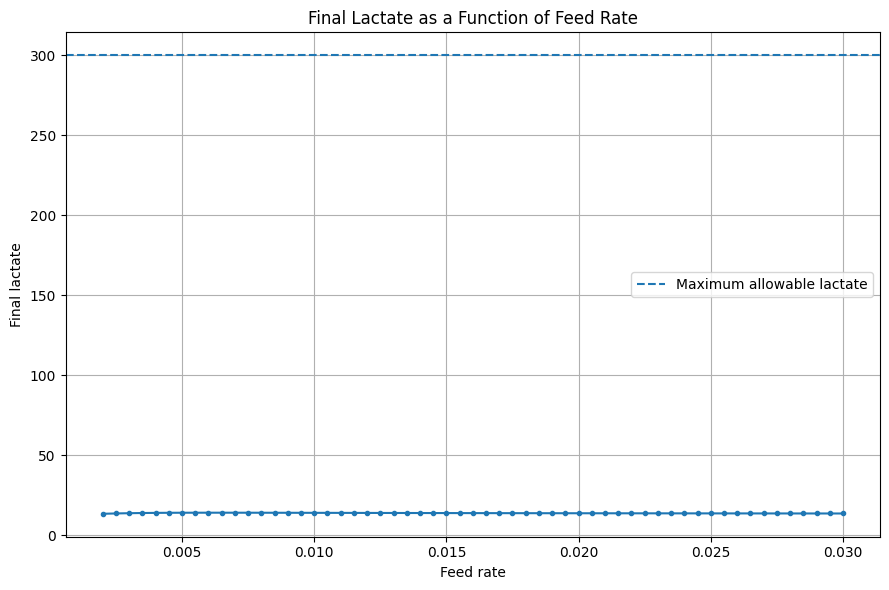

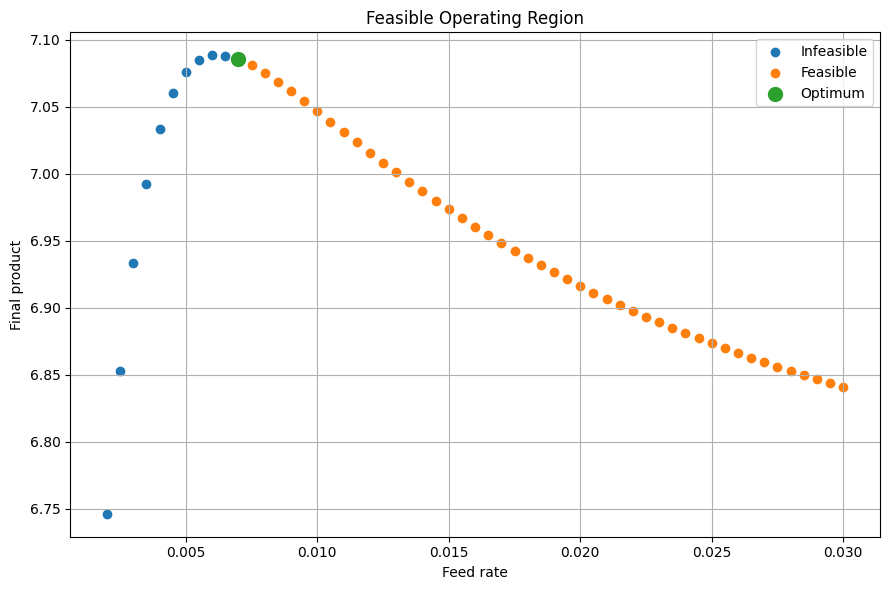


Phase 12 optimization complete.


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.integrate import trapezoid

# ============================================================
# Configuration
# ============================================================

PARAMETER_PATH = "data/processed/fitted_parameters.csv"

RESULTS_DIR = "data/processed"
FIGURE_DIR = "figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Load calibrated parameters
# ============================================================

parameter_table = pd.read_csv(PARAMETER_PATH)

calibrated_parameters = dict(
    zip(
        parameter_table["parameter"],
        parameter_table["fitted_value"]
    )
)

# Fixed process parameters
calibrated_parameters["F"] = 0.01
calibrated_parameters["G_feed"] = 50.0

# Must match the value used during calibration
calibrated_parameters["qL"] = 0.02


# ============================================================
# Initial conditions
# ============================================================

INITIAL_CONDITIONS = [
    1.0,    # viable cells
    0.0,    # dead cells
    20.0,   # glucose
    0.0,    # lactate
    0.0,    # product
    1.0     # volume
]


# ============================================================
# Simulation settings
# ============================================================

TIME = np.linspace(0, 120, 500)


# ============================================================
# Simulation function
# ============================================================

def simulate(parameters):

    solution = solve_ivp(
        bioreactor_model,
        (TIME[0], TIME[-1]),
        INITIAL_CONDITIONS,
        args=(parameters,),
        t_eval=TIME,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    if not np.all(np.isfinite(solution.y)):
        raise RuntimeError(
            "Simulation produced non-finite values."
        )

    return solution


# ============================================================
# Calculate process outputs
# ============================================================

def calculate_outputs(solution):

    Xv = solution.y[0]
    Xd = solution.y[1]
    G = solution.y[2]
    L = solution.y[3]
    P = solution.y[4]
    V = solution.y[5]

    max_viable_cells = np.max(Xv)

    final_viable_cells = Xv[-1]

    final_dead_cells = Xd[-1]

    final_glucose = G[-1]

    final_lactate = L[-1]

    final_product = P[-1]

    final_volume = V[-1]

    IVCD = trapezoid(Xv, solution.t)

    return {
        "max_viable_cells": max_viable_cells,
        "final_viable_cells": final_viable_cells,
        "final_dead_cells": final_dead_cells,
        "final_glucose": final_glucose,
        "final_lactate": final_lactate,
        "final_product": final_product,
        "final_volume": final_volume,
        "IVCD": IVCD
    }


# ============================================================
# Baseline process
# ============================================================

baseline_solution = simulate(calibrated_parameters)

baseline_outputs = calculate_outputs(
    baseline_solution
)

baseline_product = baseline_outputs["final_product"]


print("\nBaseline process")
print("----------------------------")

for name, value in baseline_outputs.items():
    print(f"{name}: {value:.4f}")


# ============================================================
# Define feed-rate search space
# ============================================================

feed_rates = np.linspace(
    0.002,
    0.030,
    57
)


# ============================================================
# Run optimization sweep
# ============================================================

optimization_results = []


for feed_rate in feed_rates:

    parameters = calibrated_parameters.copy()

    parameters["F"] = feed_rate

    solution = simulate(parameters)

    outputs = calculate_outputs(solution)

    outputs["feed_rate"] = feed_rate

    optimization_results.append(outputs)


optimization_df = pd.DataFrame(
    optimization_results
)


# ============================================================
# Calculate improvement over baseline
# ============================================================

optimization_df["product_improvement_percent"] = (
    (
        optimization_df["final_product"]
        - baseline_product
    )
    / baseline_product
) * 100


# ============================================================
# Apply process constraints
# ============================================================

# Example practical constraints:
#
# 1. Maintain a minimum final viable-cell concentration
# 2. Avoid excessive final lactate
#
# These are deliberately explicit so that the optimization
# objective is transparent and reproducible.

MIN_FINAL_VIABLE_CELLS = 20.0

MAX_FINAL_LACTATE = 300.0


optimization_df["feasible"] = (
    (optimization_df["final_viable_cells"]
     >= MIN_FINAL_VIABLE_CELLS)
    &
    (optimization_df["final_lactate"]
     <= MAX_FINAL_LACTATE)
)


# ============================================================
# Identify optimal feasible process
# ============================================================

feasible_df = optimization_df[
    optimization_df["feasible"]
].copy()


if feasible_df.empty:

    raise RuntimeError(
        "No feasible operating conditions were found. "
        "Consider relaxing the process constraints."
    )


optimal_row = feasible_df.loc[
    feasible_df["final_product"].idxmax()
]


optimal_feed_rate = optimal_row["feed_rate"]

optimal_product = optimal_row["final_product"]


# ============================================================
# Print optimization results
# ============================================================

print("\n")
print("Process optimization")
print("============================")

print(
    f"Optimal feed rate: "
    f"{optimal_feed_rate:.5f}"
)

print(
    f"Optimal final product: "
    f"{optimal_product:.4f}"
)

print(
    f"Product improvement: "
    f"{optimal_row['product_improvement_percent']:.2f}%"
)

print(
    f"Final viable cells: "
    f"{optimal_row['final_viable_cells']:.4f}"
)

print(
    f"Final lactate: "
    f"{optimal_row['final_lactate']:.4f}"
)

print(
    f"Final glucose: "
    f"{optimal_row['final_glucose']:.4f}"
)

print(
    f"Final volume: "
    f"{optimal_row['final_volume']:.4f}"
)


# ============================================================
# Save optimization results
# ============================================================

optimization_df.to_csv(
    f"{RESULTS_DIR}/optimization_results.csv",
    index=False
)


optimal_summary = pd.DataFrame([
    {
        "baseline_feed_rate": calibrated_parameters["F"],
        "optimal_feed_rate": optimal_feed_rate,
        "baseline_final_product": baseline_product,
        "optimal_final_product": optimal_product,
        "product_improvement_percent":
            optimal_row["product_improvement_percent"],
        "optimal_final_viable_cells":
            optimal_row["final_viable_cells"],
        "optimal_final_lactate":
            optimal_row["final_lactate"],
        "optimal_final_glucose":
            optimal_row["final_glucose"],
        "optimal_final_volume":
            optimal_row["final_volume"],
        "optimal_IVCD":
            optimal_row["IVCD"]
    }
])


optimal_summary.to_csv(
    f"{RESULTS_DIR}/optimal_process.csv",
    index=False
)


# ============================================================
# Plot 1 — Product versus feed rate
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    optimization_df["feed_rate"],
    optimization_df["final_product"],
    marker="o",
    markersize=3
)

plt.axvline(
    optimal_feed_rate,
    linestyle="--",
    label="Optimal feed rate"
)

plt.scatter(
    optimal_feed_rate,
    optimal_product,
    s=80,
    zorder=5,
    label="Optimal process"
)

plt.xlabel("Feed rate")
plt.ylabel("Final product")

plt.title(
    "Final Product as a Function of Feed Rate"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/optimization_product_vs_feed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 2 — Cell growth versus feed rate
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    optimization_df["feed_rate"],
    optimization_df["max_viable_cells"],
    marker="o",
    markersize=3
)

plt.xlabel("Feed rate")

plt.ylabel("Maximum viable cells")

plt.title(
    "Maximum Viable Cells as a Function of Feed Rate"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/optimization_cells_vs_feed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 3 — Lactate versus feed rate
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    optimization_df["feed_rate"],
    optimization_df["final_lactate"],
    marker="o",
    markersize=3
)

plt.axhline(
    MAX_FINAL_LACTATE,
    linestyle="--",
    label="Maximum allowable lactate"
)

plt.xlabel("Feed rate")

plt.ylabel("Final lactate")

plt.title(
    "Final Lactate as a Function of Feed Rate"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/optimization_lactate_vs_feed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 4 — Feasible operating region
# ============================================================

plt.figure(figsize=(9, 6))

feasible = optimization_df[
    optimization_df["feasible"]
]

infeasible = optimization_df[
    ~optimization_df["feasible"]
]

plt.scatter(
    infeasible["feed_rate"],
    infeasible["final_product"],
    label="Infeasible"
)

plt.scatter(
    feasible["feed_rate"],
    feasible["final_product"],
    label="Feasible"
)

plt.scatter(
    optimal_feed_rate,
    optimal_product,
    s=100,
    label="Optimum"
)

plt.xlabel("Feed rate")

plt.ylabel("Final product")

plt.title(
    "Feasible Operating Region"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/feasible_operating_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nPhase 12 optimization complete.")


## 6 — CADET-Core downstream purification extension

### Why this architecture

The upstream fed-batch reactor is already a first-principles dynamic model with six states (`Xv`, `Xd`, `G`, `L`, `P`, `V`). Rather than rewriting those equations in CADET, this section treats the optimized reactor harvest as the input to a **mechanistic chromatography model** executed by CADET-Core through **CADET-Process**.

**Integrated digital-twin flow:**

`SciPy fed-batch twin → optimized harvest → CADET capture column → outlet chromatogram → purity/recovery analysis`

The downstream parameter values below are an **illustrative model-design layer**, not experimentally fitted resin parameters. Replace them with measured resin/column data if you later want to claim predictive purification performance.


In [22]:
!conda install -y -c conda-forge cadet
!pip install -q CADET-Process

Channels:
 - conda-forge
Platform: linux-64
Solving environment: | / done

# All requested packages already installed.



In [23]:
# Verify CADET-Core and CADET-Process are available
from CADETProcess.simulator import Cadet

cadet_simulator = Cadet()
assert cadet_simulator.check_cadet(), "CADET-Core was not detected."
print("CADET-Core is available through CADET-Process.")


Test simulation completed successfully
CADET-Core is available through CADET-Process.



### 6.1 Build the upstream-to-downstream interface

The existing optimization writes `data/processed/optimal_process.csv`. We use its final product value as the harvest product signal. Because the original notebook does not define physical concentration units for `P`, this section normalizes the harvest signal before passing it to CADET. That keeps the integration honest while still demonstrating the software workflow.


In [24]:
import os
import numpy as np
import pandas as pd

OPTIMAL_PROCESS_PATH = "data/processed/optimal_process.csv"

optimal_process = pd.read_csv(OPTIMAL_PROCESS_PATH)
harvest_product_signal = float(optimal_process.loc[0, "optimal_final_product"])

# Convert the upstream product state into a normalized CADET feed concentration.
# The notebook's P state has no explicit physical concentration unit, so this is
# deliberately a relative scaling rather than a claim of mg/mL or mM.
product_feed_conc = 10.0

# Illustrative impurity burden for the downstream demonstration.
# Replace with a measured host-cell-protein / impurity concentration when available.
impurity_feed_conc = 4.0

upstream_to_downstream = pd.DataFrame({
    "quantity": ["upstream_product_signal", "CADET_product_feed", "CADET_impurity_feed"],
    "value": [harvest_product_signal, product_feed_conc, impurity_feed_conc],
    "interpretation": [
        "Output of optimized fed-batch twin",
        "Normalized product concentration for CADET demo",
        "Illustrative impurity concentration"
    ]
})

upstream_to_downstream


,quantity,value,interpretation
0,upstream_product_signal,7.085442,Output of optimized fed-batch twin
1,CADET_product_feed,10.000000,Normalized product concentration for CADET demo
2,CADET_impurity_feed,4.000000,Illustrative impurity concentration



### 6.2 Define the CADET chromatography model

This example uses two components (`Product`, `Impurity`), a competitive Langmuir binding model, and a `LumpedRateModelWithoutPores` column. The stronger product affinity creates a distinct retention profile and gives us a simple capture/separation demonstration.


In [25]:
from CADETProcess.processModel import (
    ComponentSystem,
    Langmuir,
    Inlet,
    LumpedRateModelWithoutPores,
    Outlet,
    FlowSheet,
    Process,
)

# -----------------------------
# Component system
# -----------------------------
component_system = ComponentSystem()
component_system.add_component("Product")
component_system.add_component("Impurity")

# -----------------------------
# Competitive Langmuir binding
# -----------------------------
binding_model = Langmuir(component_system, name="capture_langmuir")
binding_model.is_kinetic = False

# Illustrative affinities: product is retained more strongly than impurity.
binding_model.adsorption_rate = [0.04, 0.015]
binding_model.desorption_rate = [0.8, 1.2]
binding_model.capacity = [120.0, 80.0]

# -----------------------------
# Unit operations
# -----------------------------
feed = Inlet(component_system, name="feed")
feed.c = [product_feed_conc, impurity_feed_conc]

eluent = Inlet(component_system, name="eluent")
eluent.c = [0.0, 0.0]

column = LumpedRateModelWithoutPores(component_system, name="capture_column")
column.binding_model = binding_model
column.length = 0.20          # m
column.diameter = 0.010       # m
column.axial_dispersion = 4.7e-7
column.total_porosity = 0.70
column.solution_recorder.write_solution_bulk = True

outlet = Outlet(component_system, name="outlet")

# -----------------------------
# Flow sheet
# -----------------------------
flow_sheet = FlowSheet(component_system)
flow_sheet.add_unit(feed, feed_inlet=True)
flow_sheet.add_unit(eluent, eluent_inlet=True)
flow_sheet.add_unit(column)
flow_sheet.add_unit(outlet, product_outlet=True)

flow_sheet.add_connection(feed, column)
flow_sheet.add_connection(eluent, column)
flow_sheet.add_connection(column, outlet)

print("Required column parameters satisfied:", column.check_required_parameters())


Required column parameters satisfied: True



### 6.3 Define load and elution events

CADET-Process uses dynamic events to switch flow rates. Here the feed is active for the first 60 seconds and the eluent then carries retained species through the column for the rest of the 10-minute cycle.


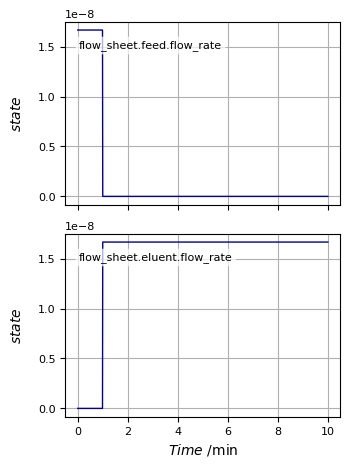

In [26]:
process = Process(flow_sheet, "digital_twin_capture")

# 1 mL/min in m^3/s
Q = 1.0e-6 / 60.0

process.add_event("feed_on", "flow_sheet.feed.flow_rate", Q)
process.add_event("feed_off", "flow_sheet.feed.flow_rate", 0.0)
process.add_event("eluent_on", "flow_sheet.eluent.flow_rate", Q)
process.add_event("eluent_off", "flow_sheet.eluent.flow_rate", 0.0)

process.add_duration("feed_duration")
process.add_event_dependency("eluent_on", ["feed_off"])
process.add_event_dependency("eluent_off", ["feed_on"])
process.add_event_dependency("feed_off", ["feed_on", "feed_duration"], [1, 1])

process.cycle_time = 600.0
process.feed_duration.time = 60.0

_ = process.plot_events()



### 6.4 Execute CADET-Core and inspect the chromatogram


Exit code: 0
Exit message: 
Simulation time [s]: 0.19923830032348633


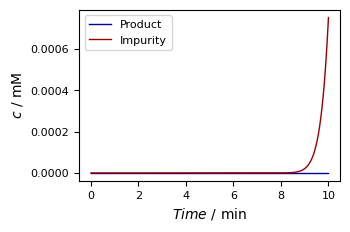

In [27]:
from CADETProcess.simulator import Cadet

process_simulator = Cadet()
process_simulator.time_resolution = 1.0

simulation_results = process_simulator.simulate(process)

print("Exit code:", simulation_results.exit_flag)
print("Exit message:", simulation_results.exit_message)
print("Simulation time [s]:", simulation_results.time_elapsed)

_ = simulation_results.solution.capture_column.outlet.plot(
    components=["Product", "Impurity"]
)



### 6.5 Export CADET outputs for the Streamlit digital twin

The exact shape of `SolutionIO` is managed by CADET-Process. This cell converts the column outlet to a simple table that your Streamlit app can read alongside the upstream trajectories.


In [28]:
# CADET-Process SolutionIO exposes time and solution arrays.
# Convert them into a tidy dataframe for plotting / app integration.
outlet_solution = simulation_results.solution.capture_column.outlet

time_s = np.asarray(outlet_solution.time)
concentration = np.asarray(outlet_solution.solution)

# Depending on CADET-Process version, solution may be [time, component]
# or include a singleton dimension. Remove singleton dimensions safely.
concentration = np.squeeze(concentration)

if concentration.ndim != 2:
    raise ValueError(f"Unexpected outlet solution shape: {concentration.shape}")

# Orient matrix as [time, component].
if concentration.shape[0] != len(time_s) and concentration.shape[1] == len(time_s):
    concentration = concentration.T

cadet_outlet_df = pd.DataFrame({
    "time_s": time_s,
    "Product": concentration[:, 0],
    "Impurity": concentration[:, 1],
})

os.makedirs("data/processed", exist_ok=True)
cadet_outlet_df.to_csv("data/processed/cadet_capture_outlet.csv", index=False)

cadet_outlet_df.head()


,time_s,Product,Impurity
0,0.0,0.000000e+00,0.000000e+00
1,1.0,-5.485327e-131,-1.069467e-116
2,2.0,-2.670390e-121,-2.567778e-107
3,3.0,-2.419098e-116,4.293135e-103
4,4.0,-3.812851e-113,2.187047e-99



### 6.6 Quantify simple separation metrics

These metrics are intentionally transparent and can be replaced later with CADET-Process fractionation optimization. For a portfolio demonstration, they show that the CADET simulation is not just visualized — it is quantitatively evaluated.


In [32]:
from scipy.integrate import trapezoid

product_mass_signal = trapezoid(cadet_outlet_df["Product"], cadet_outlet_df["time_s"])
impurity_mass_signal = trapezoid(cadet_outlet_df["Impurity"], cadet_outlet_df["time_s"])

total_signal = product_mass_signal + impurity_mass_signal
apparent_purity = product_mass_signal / total_signal if total_signal > 0 else np.nan

peak_product_time = cadet_outlet_df.loc[cadet_outlet_df["Product"].idxmax(), "time_s"]
peak_impurity_time = cadet_outlet_df.loc[cadet_outlet_df["Impurity"].idxmax(), "time_s"]
peak_separation_s = peak_product_time - peak_impurity_time

cadet_metrics = pd.DataFrame([{
    "product_integrated_signal": product_mass_signal,
    "impurity_integrated_signal": impurity_mass_signal,
    "apparent_product_purity": apparent_purity,
    "product_peak_time_s": peak_product_time,
    "impurity_peak_time_s": peak_impurity_time,
    "peak_separation_s": peak_separation_s,
}])

cadet_metrics.to_csv("data/processed/cadet_capture_metrics.csv", index=False)
cadet_metrics.T


,0
product_integrated_signal,1.008375e-23
impurity_integrated_signal,1.351559e-02
apparent_product_purity,7.460830e-22
product_peak_time_s,6.000000e+02
impurity_peak_time_s,6.000000e+02
peak_separation_s,0.000000e+00


##6 — Interactive Digital Twin

### Integrated Streamlit dashboard

The app now includes a sidebar module selector with **Upstream Reactor** and **Downstream CADET Purification** views. Run the CADET simulation/export cells before launching Streamlit if you want the downstream view to display the saved chromatogram and separation metrics.


In [29]:
# Install Streamlit if not already installed
!pip install streamlit
!pip install plotly
!pip install scipy

In [31]:
%%writefile app.py
import sys
import os

import numpy as np
import pandas as pd
import streamlit as st
import plotly.graph_objects as go

from scipy.integrate import solve_ivp


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = os.getcwd()
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
PROCESSED_PATH = os.path.join(PROJECT_ROOT, "data", "processed")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

PARAMETER_PATH = os.path.join(PROCESSED_PATH, "fitted_parameters.csv")
CADET_OUTLET_PATH = os.path.join(PROCESSED_PATH, "cadet_capture_outlet.csv")
CADET_METRICS_PATH = os.path.join(PROCESSED_PATH, "cadet_capture_metrics.csv")
OPTIMAL_PROCESS_PATH = os.path.join(PROCESSED_PATH, "optimal_process.csv")


# ============================================================
# Page configuration
# ============================================================

st.set_page_config(
    page_title="Integrated Bioprocess Digital Twin",
    page_icon="🧬",
    layout="wide"
)

st.title("🧬 Integrated Bioprocess Digital Twin")
st.markdown(
    """
    **Mechanistic upstream + downstream process simulation by Denis Gospodinov**

    This portfolio application combines a custom SciPy fed-batch mammalian-cell
    model with a CADET-Core / CADET-Process chromatography model.
    """
)

mode = st.sidebar.radio(
    "Digital Twin Module",
    ["Upstream Reactor", "Downstream CADET Purification"],
    index=0,
)

st.sidebar.markdown("---")
st.sidebar.caption(
    "Upstream: SciPy ODE model\n\n"
    "Downstream: CADET-Core via CADET-Process"
)


# ============================================================
# Upstream model
# ============================================================

def bioreactor_model(t, y, params):
    Xv, Xd, G, L, P, V = y

    mu_max = params["mu_max"]
    K_G = params["K_G"]
    kd = params["kd"]
    qG = params["qG"]
    qL = params["qL"]
    qP = params["qP"]
    F = params["F"]
    G_feed = params["G_feed"]

    mu = mu_max * G / (K_G + G)
    dXv_dt = (mu - kd) * Xv

    if Xv <= 0 and dXv_dt < 0:
        dXv_dt = 0

    dXd_dt = kd * Xv

    glucose_limitation = G / (K_G + G)
    dG_dt = (
        -qG * Xv * glucose_limitation
        + (F / V) * (G_feed - G)
    )

    if G <= 0 and dG_dt < 0:
        dG_dt = 0

    dL_dt = qL * Xv - (F / V) * L
    dP_dt = qP * Xv - (F / V) * P
    dV_dt = F

    return [dXv_dt, dXd_dt, dG_dt, dL_dt, dP_dt, dV_dt]


@st.cache_data
def load_parameters():
    if os.path.exists(PARAMETER_PATH):
        table = pd.read_csv(PARAMETER_PATH)
        params = dict(zip(table["parameter"], table["fitted_value"]))
    else:
        params = {
            "mu_max": 0.03,
            "K_G": 1.0,
            "kd": 0.003,
            "qG": 0.05,
            "qP": 0.01,
        }

    params["F"] = 0.01
    params["G_feed"] = 50.0
    params["qL"] = 0.02
    return params


@st.cache_data
def run_simulation(parameter_values, total_time):
    parameter_dict = dict(parameter_values)
    time = np.linspace(0, total_time, 500)

    solution = solve_ivp(
        bioreactor_model,
        (0, total_time),
        [1.0, 0.0, 20.0, 0.0, 0.0, 1.0],
        args=(parameter_dict,),
        t_eval=time,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution


# ============================================================
# UPSTREAM VIEW
# ============================================================

if mode == "Upstream Reactor":
    st.header("Upstream Reactor Digital Twin")
    st.write(
        "Interactively explore the calibrated fed-batch model and observe how "
        "process and biological parameters affect cells, metabolites, product, "
        "and reactor volume."
    )

    base_parameters = load_parameters()

    st.sidebar.header("Upstream Process Controls")

    simulation_time = st.sidebar.slider(
        "Simulation time (hours)", 24, 240, 120, 12
    )

    feed_rate = st.sidebar.slider(
        "Feed rate F",
        0.002, 0.030,
        float(base_parameters["F"]),
        0.001,
        format="%.3f",
    )

    feed_glucose = st.sidebar.slider(
        "Feed glucose concentration",
        10.0, 100.0,
        float(base_parameters["G_feed"]),
        5.0,
    )

    st.sidebar.header("Biological Parameters")

    mu_max = st.sidebar.slider(
        "Maximum growth rate μmax",
        0.005, 0.10,
        float(base_parameters["mu_max"]),
        0.001,
        format="%.3f",
    )

    K_G = st.sidebar.slider(
        "Glucose half-saturation K_G",
        0.1, 10.0,
        float(base_parameters["K_G"]),
        0.1,
    )

    kd = st.sidebar.slider(
        "Cell death rate kd",
        0.0001, 0.03,
        float(base_parameters["kd"]),
        0.001,
        format="%.4f",
    )

    qG = st.sidebar.slider(
        "Glucose consumption qG",
        0.005, 0.20,
        float(base_parameters["qG"]),
        0.005,
    )

    qL = st.sidebar.slider(
        "Lactate production qL",
        0.001, 0.10,
        float(base_parameters["qL"]),
        0.005,
    )

    qP = st.sidebar.slider(
        "Product formation qP",
        0.001, 0.05,
        float(base_parameters["qP"]),
        0.001,
    )

    parameters = {
        "mu_max": mu_max,
        "K_G": K_G,
        "kd": kd,
        "qG": qG,
        "qL": qL,
        "qP": qP,
        "F": feed_rate,
        "G_feed": feed_glucose,
    }

    try:
        solution = run_simulation(
            tuple(sorted(parameters.items())),
            simulation_time,
        )
    except Exception as error:
        st.error(f"Simulation failed: {error}")
        st.stop()

    time = solution.t
    Xv, Xd, G, L, P, V = solution.y

    max_viable_cells = np.max(Xv)
    final_viable_cells = Xv[-1]
    final_dead_cells = Xd[-1]
    final_glucose = G[-1]
    final_lactate = L[-1]
    final_product = P[-1]
    final_volume = V[-1]

    st.subheader("Process Performance")
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Final Product", f"{final_product:.2f}")
    c2.metric("Max Viable Cells", f"{max_viable_cells:.2f}")
    c3.metric("Final Glucose", f"{final_glucose:.2f}")
    c4.metric("Final Lactate", f"{final_lactate:.2f}")

    c5, c6 = st.columns(2)
    c5.metric("Final Viable Cells", f"{final_viable_cells:.2f}")
    c6.metric("Final Reactor Volume", f"{final_volume:.2f}")

    fig_cells = go.Figure()
    fig_cells.add_trace(go.Scatter(x=time, y=Xv, mode="lines", name="Viable cells"))
    fig_cells.add_trace(go.Scatter(x=time, y=Xd, mode="lines", name="Dead cells"))
    fig_cells.update_layout(
        title="Cell Growth",
        xaxis_title="Time (hours)",
        yaxis_title="Cell concentration",
        hovermode="x unified",
    )
    st.plotly_chart(fig_cells, use_container_width=True)

    fig_metabolites = go.Figure()
    fig_metabolites.add_trace(go.Scatter(x=time, y=G, mode="lines", name="Glucose"))
    fig_metabolites.add_trace(go.Scatter(x=time, y=L, mode="lines", name="Lactate"))
    fig_metabolites.update_layout(
        title="Metabolic Profile",
        xaxis_title="Time (hours)",
        yaxis_title="Concentration",
        hovermode="x unified",
    )
    st.plotly_chart(fig_metabolites, use_container_width=True)

    fig_product = go.Figure()
    fig_product.add_trace(go.Scatter(x=time, y=P, mode="lines", name="Product"))
    fig_product.update_layout(
        title="Product Formation",
        xaxis_title="Time (hours)",
        yaxis_title="Product concentration",
        hovermode="x unified",
    )
    st.plotly_chart(fig_product, use_container_width=True)

    fig_volume = go.Figure()
    fig_volume.add_trace(go.Scatter(x=time, y=V, mode="lines", name="Volume"))
    fig_volume.update_layout(
        title="Reactor Volume",
        xaxis_title="Time (hours)",
        yaxis_title="Volume",
        hovermode="x unified",
    )
    st.plotly_chart(fig_volume, use_container_width=True)

    summary = pd.DataFrame({
        "Metric": [
            "Maximum viable cells",
            "Final viable cells",
            "Final dead cells",
            "Final glucose",
            "Final lactate",
            "Final product",
            "Final volume",
        ],
        "Value": [
            max_viable_cells,
            final_viable_cells,
            final_dead_cells,
            final_glucose,
            final_lactate,
            final_product,
            final_volume,
        ],
    })

    st.subheader("Simulation Summary")
    st.dataframe(summary, use_container_width=True, hide_index=True)

    with st.expander("View Model Parameters"):
        st.dataframe(
            pd.DataFrame({
                "Parameter": list(parameters.keys()),
                "Value": list(parameters.values()),
            }),
            use_container_width=True,
            hide_index=True,
        )

    simulation_data = pd.DataFrame({
        "time_hr": time,
        "viable_cells": Xv,
        "dead_cells": Xd,
        "glucose": G,
        "lactate": L,
        "product": P,
        "volume": V,
    })

    st.download_button(
        "Download Upstream Simulation",
        data=simulation_data.to_csv(index=False),
        file_name="upstream_digital_twin_simulation.csv",
        mime="text/csv",
    )


# ============================================================
# DOWNSTREAM CADET VIEW
# ============================================================

else:
    st.header("Downstream CADET Purification")
    st.write(
        "This module visualizes the mechanistic chromatography simulation "
        "executed with CADET-Core through CADET-Process. The optimized upstream "
        "harvest is the logical input to the capture step."
    )

    missing = [
        path for path in [CADET_OUTLET_PATH, CADET_METRICS_PATH]
        if not os.path.exists(path)
    ]

    if missing:
        st.warning(
            "CADET result files are not available yet. Run the notebook's "
            "CADET downstream simulation and export cells before launching "
            "this dashboard."
        )
        st.code(
            "Expected files:\n"
            "data/processed/cadet_capture_outlet.csv\n"
            "data/processed/cadet_capture_metrics.csv"
        )
        st.stop()

    @st.cache_data
    def load_cadet_results():
        outlet = pd.read_csv(CADET_OUTLET_PATH)
        metrics = pd.read_csv(CADET_METRICS_PATH)
        return outlet, metrics

    cadet_outlet, cadet_metrics = load_cadet_results()
    m = cadet_metrics.iloc[0]

    upstream_signal = np.nan
    if os.path.exists(OPTIMAL_PROCESS_PATH):
        optimal = pd.read_csv(OPTIMAL_PROCESS_PATH)
        if "optimal_final_product" in optimal.columns:
            upstream_signal = float(optimal.loc[0, "optimal_final_product"])

    st.subheader("Integrated Process KPIs")
    c1, c2, c3, c4 = st.columns(4)

    if np.isfinite(upstream_signal):
        c1.metric("Upstream Harvest Signal", f"{upstream_signal:.2f}")
    else:
        c1.metric("Upstream Harvest Signal", "N/A")

    c2.metric(
        "Apparent Product Purity",
        f"{100.0 * float(m['apparent_product_purity']):.1f}%"
    )
    c3.metric(
        "Product Peak Time",
        f"{float(m['product_peak_time_s']):.0f} s"
    )
    c4.metric(
        "Peak Separation",
        f"{float(m['peak_separation_s']):.0f} s"
    )

    fig_chrom = go.Figure()
    fig_chrom.add_trace(
        go.Scatter(
            x=cadet_outlet["time_s"],
            y=cadet_outlet["Product"],
            mode="lines",
            name="Product",
        )
    )
    fig_chrom.add_trace(
        go.Scatter(
            x=cadet_outlet["time_s"],
            y=cadet_outlet["Impurity"],
            mode="lines",
            name="Impurity",
        )
    )
    fig_chrom.update_layout(
        title="CADET Capture Column Outlet Chromatogram",
        xaxis_title="Time (s)",
        yaxis_title="Outlet concentration / normalized signal",
        hovermode="x unified",
    )
    st.plotly_chart(fig_chrom, use_container_width=True)

    integral_df = pd.DataFrame({
        "Species": ["Product", "Impurity"],
        "Integrated outlet signal": [
            float(m["product_integrated_signal"]),
            float(m["impurity_integrated_signal"]),
        ],
    })

    fig_integrals = go.Figure()
    fig_integrals.add_trace(
        go.Bar(
            x=integral_df["Species"],
            y=integral_df["Integrated outlet signal"],
            name="Integrated signal",
        )
    )
    fig_integrals.update_layout(
        title="Integrated Outlet Signal",
        xaxis_title="Species",
        yaxis_title="Time-integrated signal",
    )
    st.plotly_chart(fig_integrals, use_container_width=True)

    peak_df = pd.DataFrame({
        "Species": ["Product", "Impurity"],
        "Peak time (s)": [
            float(m["product_peak_time_s"]),
            float(m["impurity_peak_time_s"]),
        ],
    })

    st.subheader("Separation Summary")
    c_left, c_right = st.columns(2)

    with c_left:
        st.dataframe(integral_df, use_container_width=True, hide_index=True)

    with c_right:
        st.dataframe(peak_df, use_container_width=True, hide_index=True)

    with st.expander("What the CADET module demonstrates"):
        st.markdown(
            """
            - Multi-component chromatography modeling
            - Competitive Langmuir adsorption
            - Mechanistic column transport
            - Dynamic load / elution events
            - CADET-Core simulation through CADET-Process
            - Chromatogram extraction and quantitative separation analysis
            - Integration with the optimized upstream bioreactor workflow

            **Portfolio note:** the chromatography parameters in this project are
            illustrative unless replaced with experimentally fitted resin data.
            """
        )

    st.download_button(
        "Download CADET Chromatogram",
        data=cadet_outlet.to_csv(index=False),
        file_name="cadet_capture_outlet.csv",
        mime="text/csv",
    )


# ============================================================
# Footer
# ============================================================

st.markdown("---")
st.caption(
    "Integrated mechanistic bioprocess digital twin | "
    "Python • SciPy • CADET-Core • CADET-Process • Streamlit • Plotly"
)


Overwriting app.py


In [34]:
!pip install pyngrok

from pyngrok import ngrok
import subprocess
import os

# Kill any running ngrok tunnels
ngrok.kill()


# Get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token()"NGROK_AUTHTOKEN")

# Start ngrok tunnel for Streamlit on port 8501
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run the Streamlit app in the background
# Using subprocess.Popen to run it non-blocking
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "True"])

Streamlit App URL: NgrokTunnel: "https://ruby-calvus-nondomestically.ngrok-free.dev" -> "http://localhost:8501"


<Popen: returncode: None args: ['streamlit', 'run', 'app.py', '--server.port...>


## 7 — Portfolio interpretation

After this section runs successfully, the project demonstrates two complementary mechanistic modeling stacks:

1. **Upstream:** custom first-principles fed-batch ODE model in SciPy, parameter estimation, validation, sensitivity analysis, and feed-rate optimization.
2. **Downstream:** CADET-Core simulation through CADET-Process with component definitions, binding physics, a chromatographic unit operation, dynamic process events, mechanistic simulation, and quantitative outlet analysis.
3. **Digital-twin integration:** the optimized upstream harvest becomes the logical input to the downstream capture model, and both can be surfaced in the existing Streamlit interface.

### Resume-ready project wording

**Integrated Bioprocess Digital Twin | Python, SciPy, CADET-Core, CADET-Process, Streamlit**  
Developed an end-to-end mechanistic bioprocess digital twin combining a calibrated fed-batch mammalian cell-culture ODE model with CADET-Core chromatography simulation. Performed parameter estimation, model validation, local sensitivity analysis, feed-rate optimization, dynamic downstream process simulation, and quantitative separation analysis; integrated model outputs for interactive visualization in Streamlit.

### Interactive dashboard integration

The Streamlit interface now exposes two portfolio-facing modules from one app: **Upstream Reactor** for live SciPy fed-batch simulation and **Downstream CADET Purification** for CADET chromatogram and separation analysis.


##Author

**Denis Gospodinov, PhD**